# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "c3f8"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458]] [[0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46]] [[0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46]] ... [[0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.777 0.7746666666666666 0.773] [0.745 0.745 0.745 ... 0.7813333333333334 0.7771666666666668 0.773] [0.745 0.745 0.745 ... 0.7788333333333335 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773]] [[0.747 0.747 0.747 ... 0.783 0.783 0.783] [0.747 0.747 0.747 ... 0.783 0.783 0.783] [0.747 0.747 0.747 ... 0.78 0.783 0.783] [0.747 0.747 0.747 ... 0.7906666666666666 0.7868333333333333 0.783] [0.747 0.747 0.747 ... 0.7868333333333333 0.783 0.783] [0.747 0.747 0.747 ... 0.7829999999999999 0.783 0.783]] [[0.749 0.749 0.749 ... 0.7846666666666667 0.7863333333333334 0.788] [0.749 0.749 0.749 ... 0.7846666666666667 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.78425 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.7886666666666667 0.7883333333333333 0.788] [0.749 0.749 0.749 ... 0.7866666666666667 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.7846666666666666 0.7863333333333334 0.788]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458] [0.404 0.404 0.404 ... 0.458 0.458 0.458]] [[0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46] [0.409 0.409 0.409 ... 0.46 0.46 0.46]] [[0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46] [0.411 0.411 0.411 ... 0.46 0.46 0.46]] ... [[0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.777 0.7746666666666666 0.773] [0.745 0.745 0.745 ... 0.7813333333333334 0.7771666666666668 0.773] [0.745 0.745 0.745 ... 0.7788333333333335 0.7746666666666667 0.773] [0.745 0.745 0.745 ... 0.7763333333333333 0.7746666666666667 0.773]] [[0.747 0.747 0.747 ... 0.783 0.783 0.783] [0.747 0.747 0.747 ... 0.783 0.783 0.783] [0.747 0.747 0.747 ... 0.78 0.783 0.783] [0.747 0.747 0.747 ... 0.7906666666666666 0.7868333333333333 0.783] [0.747 0.747 0.747 ... 0.7868333333333333 0.783 0.783] [0.747 0.747 0.747 ... 0.7829999999999999 0.783 0.783]] [[0.749 0.749 0.749 ... 0.7846666666666667 0.7863333333333334 0.788] [0.749 0.749 0.749 ... 0.7846666666666667 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.78425 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.7886666666666667 0.7883333333333333 0.788] [0.749 0.749 0.749 ... 0.7866666666666667 0.7863333333333333 0.788] [0.749 0.749 0.749 ... 0.7846666666666666 0.7863333333333334 0.788]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'c3f8' (lon: 6, lat: 12, year: 18, month: 12)> Size: 124kB
<Quantity([[[[0.42       0.426      0.431      ... 0.452      0.452
    0.455     ]
   [0.455      0.453      0.46       ... 0.471      0.475
    0.474     ]
   [0.476      0.479      0.481      ... 0.494      0.494
    0.497     ]
   ...
   [0.696      0.703      0.702      ... 0.718      0.719
    0.721     ]
   [0.723      0.723      0.724      ... 0.734      0.737
    0.735     ]
   [0.737      0.739      0.738      ... 0.745      0.747
    0.749     ]]

  [[0.42       0.426      0.431      ... 0.452      0.452
    0.455     ]
   [0.455      0.453      0.46       ... 0.471      0.475
    0.474     ]
   [0.476      0.479      0.481      ... 0.494      0.494
    0.497     ]
...
   [0.72733333 0.731      0.732      ... 0.74433333 0.74233333
    0.74733333]
   [0.74433333 0.744      0.75       ... 0.762      0.763
    0.759     ]
   [0.76566667 0.76566667 0.765      ... 0.77466667 0.783
    0.78633333]]

  [[0.483      0.482      0.479      ... 0.492      0.497
    0.494     ]
   [0.492      0.5        0.502      ... 0.502      0.503
    0.5       ]
   [0.513      0.515      0.519      ... 0.516      0.524
    0.526     ]
   ...
   [0.729      0.733      0.732      ... 0.747      0.743
    0.75      ]
   [0.745      0.742      0.75       ... 0.766      0.767
    0.761     ]
   [0.771      0.771      0.768      ... 0.773      0.783
    0.788     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 144B 2006 2007 2008 2009 2010 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.7763333333333333 0.783 0.7846666666666667] [0.483 0.482 0.479 ... 0.7746666666666667 0.783 0.7863333333333334] [0.483 0.482 0.479 ... 0.773 0.783 0.788]] [[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.7763333333333333 0.783 0.7846666666666667] [0.483 0.482 0.479 ... 0.7746666666666667 0.783 0.7863333333333333] [0.483 0.482 0.479 ... 0.773 0.783 0.788]] [[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.777 0.78 0.78425] [0.483 0.482 0.479 ... 0.7746666666666666 0.783 0.7863333333333333] [0.483 0.482 0.479 ... 0.773 0.783 0.788]] [[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.7813333333333334 0.7906666666666666 0.7886666666666667] [0.483 0.482 0.479 ... 0.7771666666666668 0.7868333333333333 0.7883333333333333] [0.483 0.482 0.479 ... 0.773 0.783 0.788]] [[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.7788333333333335 0.7868333333333333 0.7866666666666667] [0.483 0.482 0.479 ... 0.7746666666666667 0.783 0.7863333333333333] [0.483 0.482 0.479 ... 0.773 0.783 0.788]] [[0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] [0.42 0.426 0.431 ... 0.745 0.747 0.749] ... [0.483 0.482 0.479 ... 0.7763333333333333 0.7829999999999999 0.7846666666666666] [0.483 0.482 0.479 ... 0.7746666666666667 0.783 0.7863333333333334] [0.483 0.482 0.479 ... 0.773 0.783 0.788]]]
Units,ppt


### Longitudinal-mean

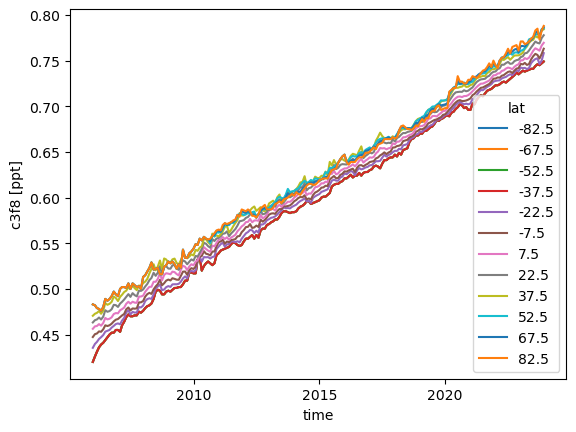

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

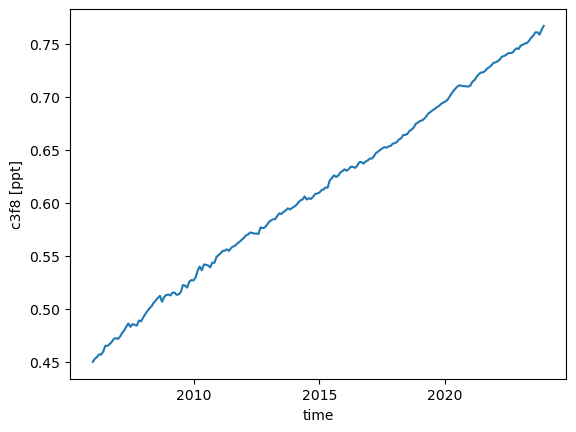

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

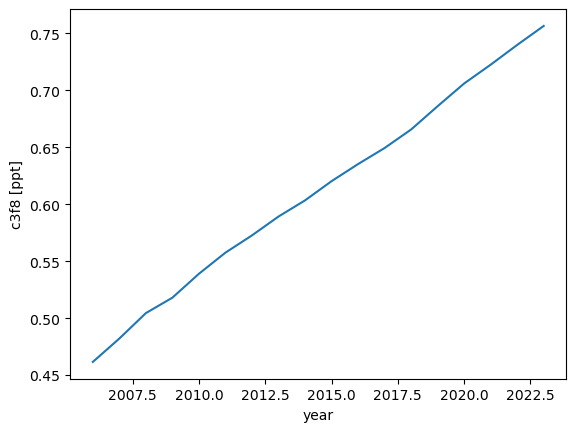

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 18)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 144B 2006 2007 2008 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3234 ... -1.281e-05
    principal-components  (year, eof) float64 2kB [] -0.06329 ... -1.951e-20

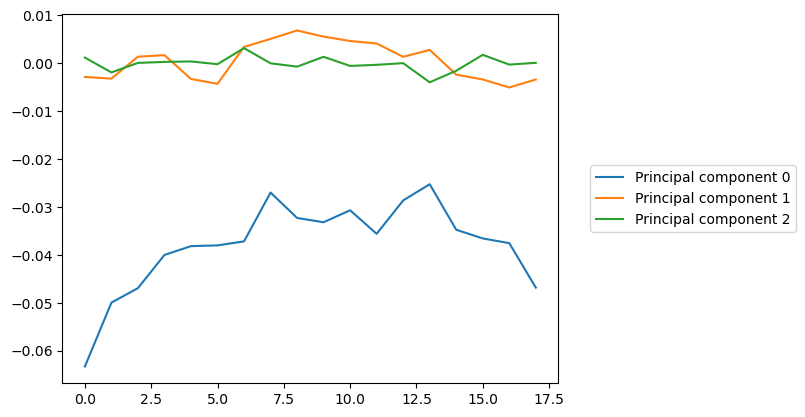

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

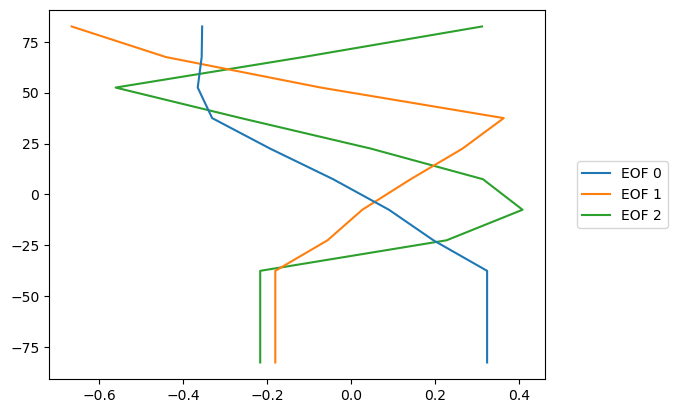

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

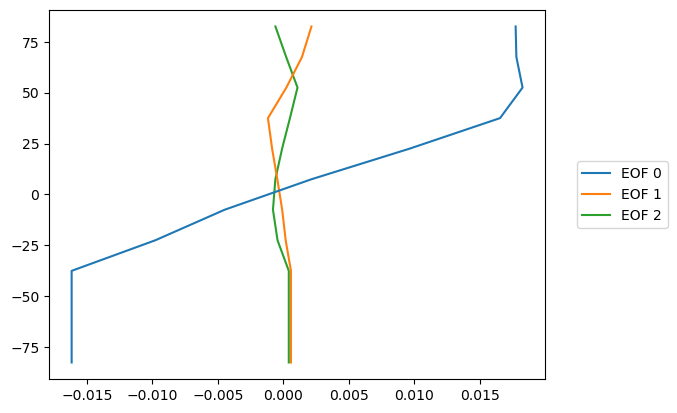

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.323404631308018] [0.3234046313080178] [0.32340463130801783] [0.32340463130801783] [0.1956276671513205] [0.0896822596338078] [-0.04323131507964276] [-0.1929668573718948] [-0.3311894716716571] [-0.36559146207093746] [-0.35613945935873526] [-0.35502201833246405]]
Units,ppt
Magnitude,[[-0.06328900487584095] [-0.049964931166880514] [-0.046943858776183484] [-0.04001480030991302] [-0.03817721342985382] [-0.03802377288963588] [-0.03718910126429595] [-0.026996437219656198] [-0.03229741041104621] [-0.033197259423367584] [-0.030694702108459756] [-0.03560841416342344] [-0.02864510683360488] [-0.025258977728687463] [-0.03475950384238234] [-0.03657170953068713] [-0.03755468097490893] [-0.04682729065003309]]
Units,dimensionless


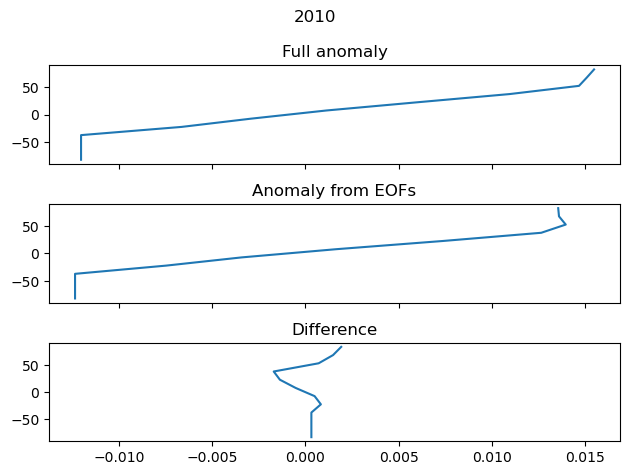

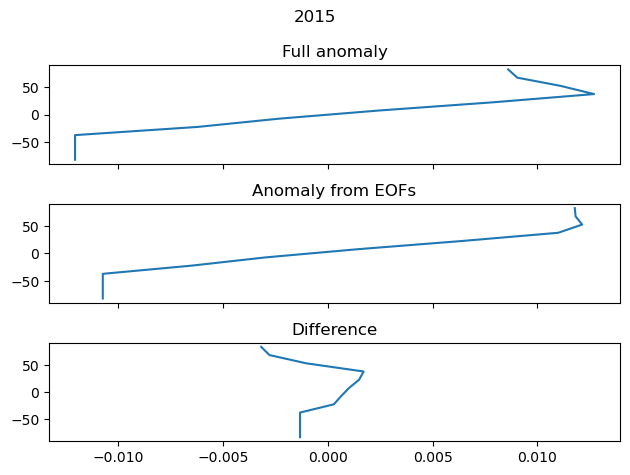

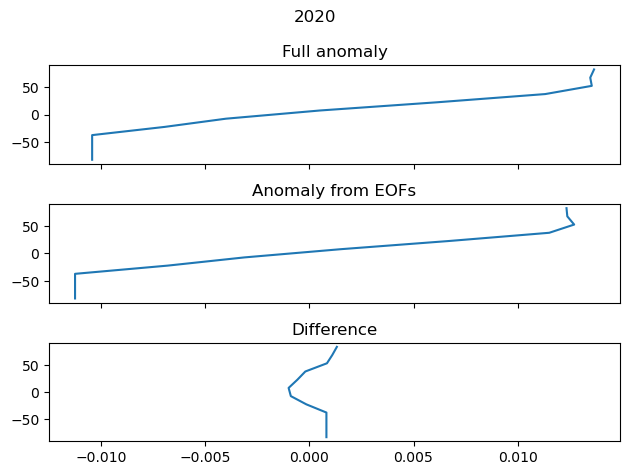

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 17878.04it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 19702.70it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/216 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 19411.00it/s]

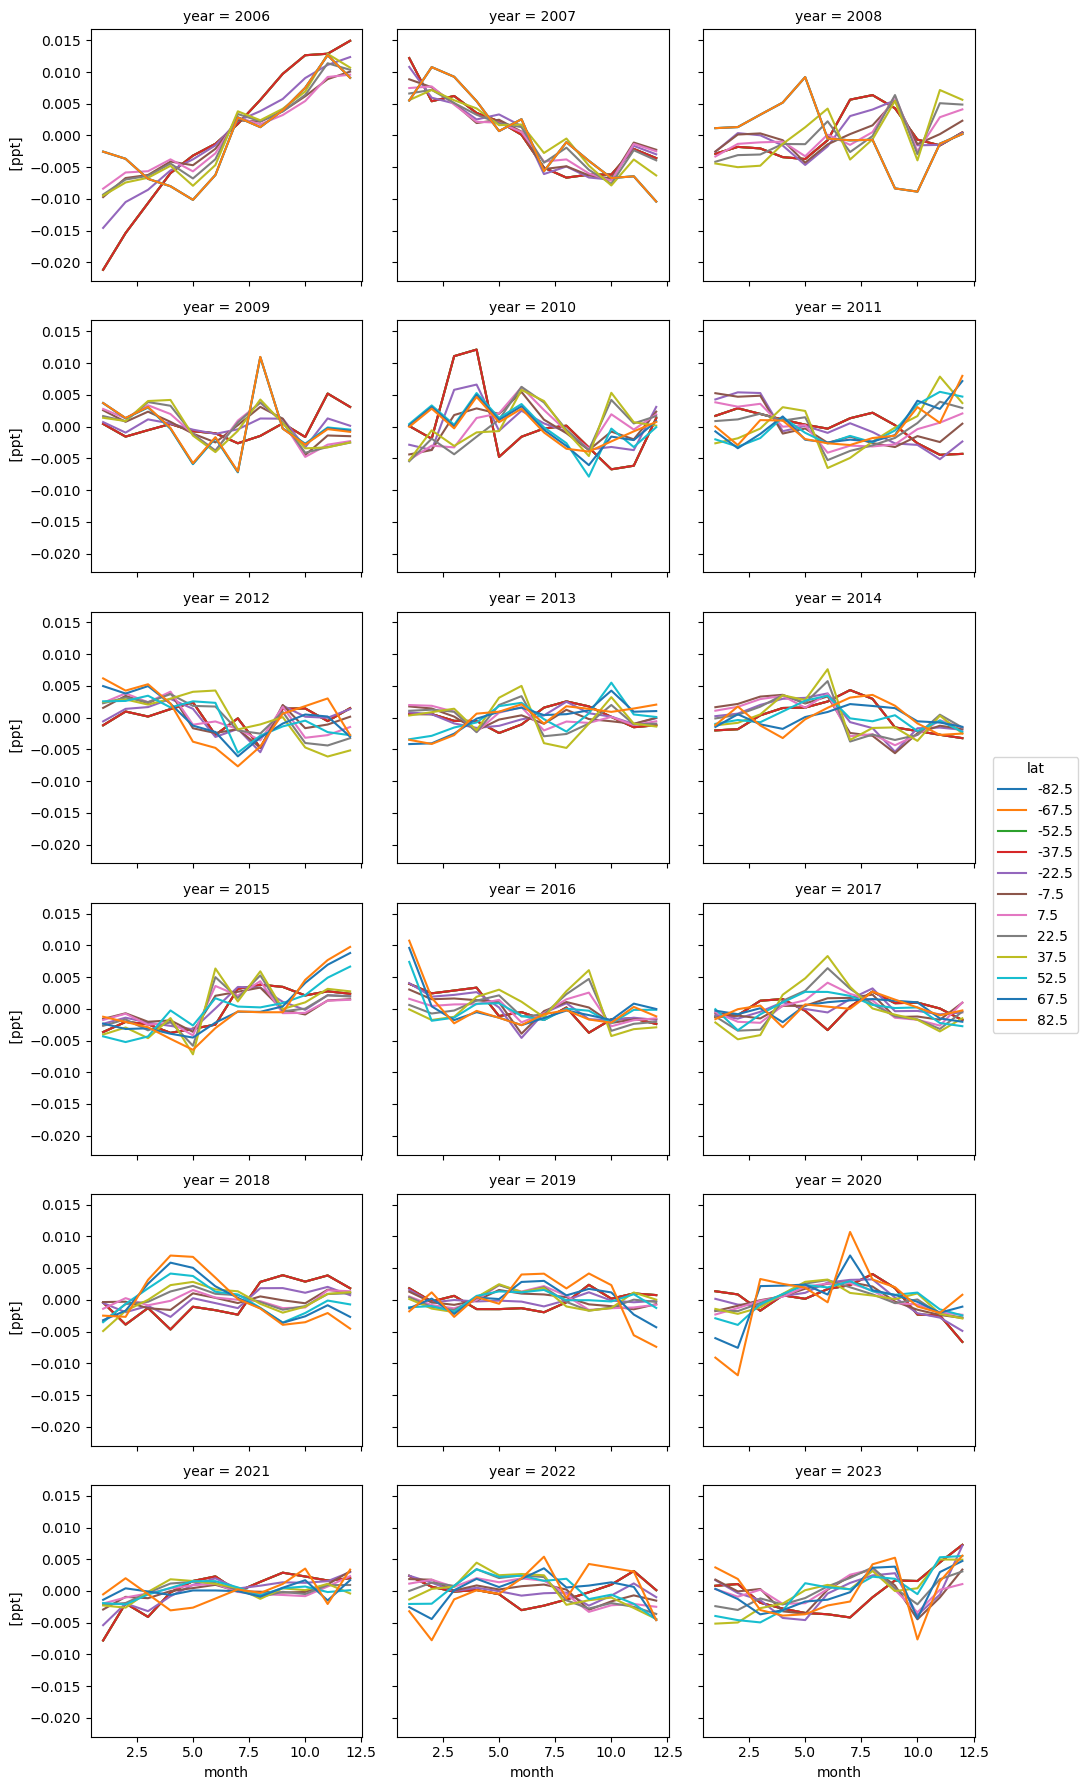

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

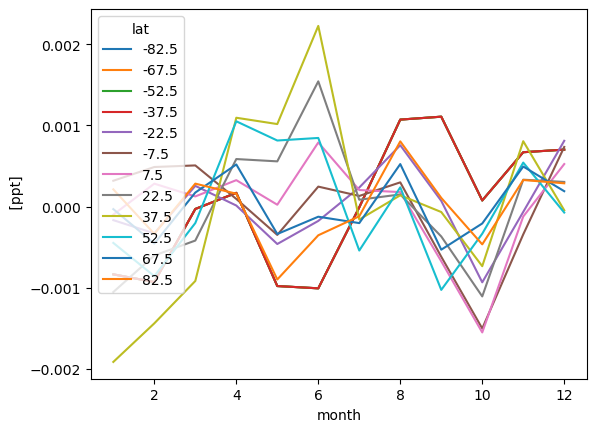

In [22]:
seasonality.plot.line(hue="lat")

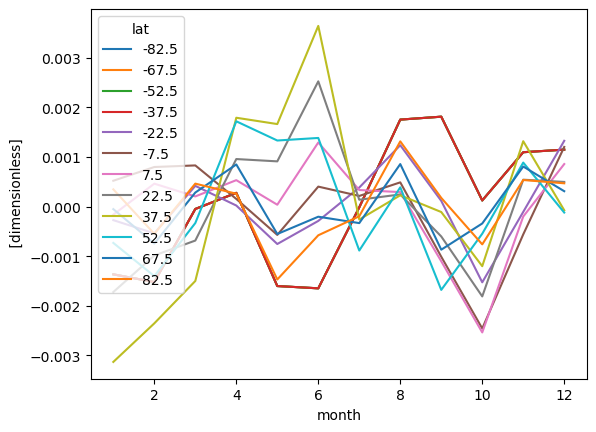

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.4615645402907725 0.48209473112273843 0.5044145550078715 0.5179602108235039 0.5389414641622761 0.5574970376058087 0.5726386416601941 0.5891843084891742 0.6033678896247158 0.6202262009840696 0.6352397262164821 0.6493450677010113 0.6656000284083673 0.6860526150951012 0.7060044556534764 0.7225048125488395 0.7398629484749302 0.7565240455565717]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.323404631308018] [0.3234046313080178] [0.32340463130801783] [0.32340463130801783] [0.1956276671513205] [0.0896822596338078] [-0.04323131507964276] [-0.1929668573718948] [-0.3311894716716571] [-0.36559146207093746] [-0.35613945935873526] [-0.35502201833246405]]
Units,ppt
Magnitude,[[-0.06328900487584095] [-0.049964931166880514] [-0.046943858776183484] [-0.04001480030991302] [-0.03817721342985382] [-0.03802377288963588] [-0.03718910126429595] [-0.026996437219656198] [-0.03229741041104621] [-0.033197259423367584] [-0.030694702108459756] [-0.03560841416342344] [-0.02864510683360488] [-0.025258977728687463] [-0.03475950384238234] [-0.03657170953068713] [-0.03755468097490893] [-0.04682729065003309]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.001367080526292965 -0.0015221985781044465 -4.9047510434451854e-05 0.00027598323360598367 -0.001602739773068092 -0.0016490125130595886 -1.548334451689773e-05 0.0017526386140071758 0.0018116860267682897 0.00012285590047697416 0.001095159326067631 0.0011472447107859266] [-0.001367080526292965 -0.0015221985781044465 -4.9047510434451854e-05 0.00027598323360598367 -0.001602739773068092 -0.0016490125130595886 -1.548334451689773e-05 0.0017526386140071758 0.0018116860267682897 0.00012285590047697416 0.001095159326067631 0.0011472447107859266] [-0.001367080526292965 -0.0015221985781044465 -4.9047510434451854e-05 0.00027598323360598367 -0.001602739773068092 -0.0016490125130595886 -1.548334451689773e-05 0.0017526386140071758 0.0018116860267682897 0.00012285590047697416 0.001095159326067631 0.0011472447107859266] [-0.001367080526292965 -0.0015221985781044465 -4.9047510434456895e-05 0.00027598323360598367 -0.001602739773068092 -0.0016490125130595886 -1.548334451689773e-05 0.0017526386140071758 0.0018116860267682897 0.00012285590047697416 0.001095159326067631 0.0011472447107859266] [-0.0002742190673320546 -0.000540959257376488 0.0004167586602252027 2.0190261687532885e-05 -0.0007554100107193859 -0.0002898725366347992 0.0003833839033800037 0.001236368809224678 0.0001144524846857562 -0.001527724674236356 -0.00010808236741579069 0.0013251072908767522] [0.0005200720452435292 0.0007970532646723376 0.0008289375344128034 0.00015314500715343462 -0.0005720522759159949 0.0004017497909391662 0.0002137022853763594 0.0004873677599344282 -0.0010119069151684219 -0.0024584474167490067 -0.0005612294244959325 0.0012015920915933436] [-0.0001638202825606937 0.00046128155728456975 0.00020384885911842396 0.0005320143870081097 3.659879560277327e-05 0.0012915782688065378 0.00033311884279526135 0.00029119432565941127 -0.001103074592677835 -0.0025379954219419626 -0.00020128367018785046 0.0008565162757892473] [-0.0017233167183367296 -0.0009868606988682547 -0.0006858509170329764 0.0009574271207441134 0.0009107658880626012 0.0025239263706616404 0.00013742074300309088 0.00024398767384356933 -0.0006030502025333382 -0.0018118854244950774 0.0005412822053093039 0.0004961327419921562] [-0.003132506207108639 -0.0023548888431402255 -0.0015008700418844179 0.0017900575531181048 0.0016626745088383166 0.003641257485931443 -0.0002618195533007719 0.0002271563300971104 -0.00011069050451355074 -0.0012024943388337487 0.001317153079367407 -7.504589353161073e-05] [-0.0007333248194535777 -0.001402745478147767 -0.00033304855905826817 0.0017183973878455987 0.0013310214293490608 0.001382730581493102 -0.0008868150890014685 0.0003869957274070245 -0.0016803102238566341 -0.0005477547816128477 0.0008859245285038704 -0.0001210835179598024] [-5.220891809469859e-05 -0.0007463131858561964 0.00028212948964930574 0.0008484640206524419 -0.0005538356160490615 -0.00020517684245112625 -0.0003338729192138813 0.0008561095060846608 -0.0008697543879049518 -0.0003413520434305854 0.0008064847550724359 0.00030931055373180176] [0.0003464077271785891 -0.0005495376836410067 0.00046176936510021124 0.0002583533663901603 -0.0014703279836197438 -0.0005794838340660997 -0.00019576443476196145 0.0013134429669873174 0.0001739454135624935 -0.000762434115282889 0.0005349503436361291 0.00046866662745989954]]
Units,dimensionless
